In [191]:
import pandas as pd

df = pd.read_csv(r'D:\Documents\Projects\DA Projects\Sales Dashboard\retail_sales_dataset.csv')
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [12]:
df1 = df.set_index('Transaction ID')
df1

,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
Transaction ID,,,,,,,,
1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...
996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
998,2023-10-29,CUST998,Female,23,Beauty,4,25,100


In [15]:
df1.filter(items = [197], axis = 0)     # Filtering based on index (in this case : Transaction ID)

,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
197,2023-03-06,CUST197,Female,42,Clothing,4,50,200


In [16]:
df1[df1['Date'].str.contains('2023-07-29')]     # Filtering based on any random record value in the dataset

,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
Transaction ID,,,,,,,,
541,2023-07-29,CUST541,Male,56,Beauty,1,500,500
980,2023-07-29,CUST980,Female,31,Electronics,3,25,75


REVENUE BY GENDER

In [55]:
df2 = df.set_index(['Gender'])        # Index is set to GENDER 

In [56]:
df2

,Transaction ID,Date,Customer ID,Age,Product Category,Quantity,Price per Unit,Total Amount
Gender,,,,,,,,
Male,1,2023-11-24,CUST001,34,Beauty,3,50,150
Female,2,2023-02-27,CUST002,26,Clothing,2,500,1000
Male,3,2023-01-13,CUST003,50,Electronics,1,30,30
Male,4,2023-05-21,CUST004,37,Clothing,1,500,500
Male,5,2023-05-06,CUST005,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...
Male,996,2023-05-16,CUST996,62,Clothing,1,50,50
Male,997,2023-11-17,CUST997,52,Beauty,3,30,90
Female,998,2023-10-29,CUST998,23,Beauty,4,25,100


In [57]:
df2 = df2.sort_index()       # Index is sorted in ascending order (in this case, alphabetically)
df2

,Transaction ID,Date,Customer ID,Age,Product Category,Quantity,Price per Unit,Total Amount
Gender,,,,,,,,
Female,500,2023-03-01,CUST500,60,Beauty,4,25,100
Female,421,2023-01-02,CUST421,37,Clothing,3,500,1500
Female,422,2023-06-20,CUST422,28,Clothing,3,30,90
Female,423,2023-03-08,CUST423,27,Clothing,1,25,25
Female,425,2023-05-15,CUST425,55,Electronics,4,30,120
...,...,...,...,...,...,...,...,...
Male,455,2023-07-01,CUST455,31,Electronics,4,25,100
Male,456,2023-10-14,CUST456,57,Electronics,2,30,60
Male,459,2023-03-21,CUST459,28,Clothing,4,300,1200


In [58]:
df2.groupby('Gender')      # Records are grouped into two groups : 1) Female, 2) Male

In [59]:
gender = df2.groupby('Gender')
amt_per_gender = gender.sum()       # Total sum is calculated per group(i.e. Female and Male)

In [60]:
rev_per_gender = amt_per_gender.filter(items = ['Total Amount'])      # Displays only the 'Total Amount' column values per group
rev_per_gender

,Total Amount
Gender,
Female,232840
Male,223160


In [131]:
gender_df = rev_per_gender.sort_values(by = 'Total Amount', ascending = False)
gender_df

,Total Amount
Gender,
Female,232840
Male,223160


REVENUE BY PRODUCTS

In [62]:
df_prod = df.set_index('Product Category')
df_prod

,Transaction ID,Date,Customer ID,Gender,Age,Quantity,Price per Unit,Total Amount
Product Category,,,,,,,,
Beauty,1,2023-11-24,CUST001,Male,34,3,50,150
Clothing,2,2023-02-27,CUST002,Female,26,2,500,1000
Electronics,3,2023-01-13,CUST003,Male,50,1,30,30
Clothing,4,2023-05-21,CUST004,Male,37,1,500,500
Beauty,5,2023-05-06,CUST005,Male,30,2,50,100
...,...,...,...,...,...,...,...,...
Clothing,996,2023-05-16,CUST996,Male,62,1,50,50
Beauty,997,2023-11-17,CUST997,Male,52,3,30,90
Beauty,998,2023-10-29,CUST998,Female,23,4,25,100


In [87]:
sorted_df = df_prod.sort_index()
amt_per_prod = sorted_df.groupby('Product Category')
tot_amt = amt_per_prod.sum()

In [88]:
amt = tot_amt.filter(items = ['Total Amount']) 
amt

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


In [112]:
tot_qty = sorted_df.groupby('Product Category').count()
qty = tot_qty.filter(items = ['Quantity'])
qty

,Quantity
Product Category,
Beauty,307
Clothing,351
Electronics,342


In [297]:
# amt.merge(qty)     # Does not work because .merge() performs 

In [114]:
qty.join(amt)

,Quantity,Total Amount
Product Category,,
Beauty,307,143515
Clothing,351,155580
Electronics,342,156905


In [236]:
prod_df = qty.join(amt)
prod_df = prod_df.sort_values(by=['Quantity', 'Total Amount'], ascending = [False, False])
prod_df

,Quantity,Total Amount
Product Category,,
Clothing,351,155580
Electronics,342,156905
Beauty,307,143515


In [137]:
pd.concat([qty,amt], join = 'outer')     # Performs only inner or outer join (Outer join by default)

,Quantity,Total Amount
Product Category,,
Beauty,307.0,NaN
Clothing,351.0,NaN
Electronics,342.0,NaN
Beauty,NaN,143515.0
Clothing,NaN,155580.0
Electronics,NaN,156905.0


REVENUE PER MONTH

In [193]:
df3 = df
df3

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [205]:
df3['Month'] = pd.DatetimeIndex(df['Date']).month    # Extracts the month part by converting Date to Datetime
df3

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
Month,,,,,,,,,,
11,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
2,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
1,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
5,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
5,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5
...,...,...,...,...,...,...,...,...,...,...
5,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5
11,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11
10,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10


In [206]:
df3 = df.set_index('Month')        # Seting the index to Month makes filtering and analysis easier
df3

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
Month,,,,,,,,,
11,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
2,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
1,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
5,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
5,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
5,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
11,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
10,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100


In [207]:
sorted_df3 = df3.sort_index().groupby('Month')         # Sorts index in ascending order(by default) and groups data by month
monthly_df = sorted_df3.count().filter(items = ['Transaction ID'])   # Filters the dataset so that we can see number of transactions only per month (PS : less clutter)

In [208]:
monthly_df

,Transaction ID
Month,
1,78
2,85
3,73
4,86
5,105
6,77
7,72
8,94
9,65


In [210]:
import numpy as np
import matplotlib.pyplot as plt

In [276]:
print(plt.style.available)
plt.style.use('seaborn-v0_8')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


<Axes: title={'center': 'REVENUE BY GENDER'}, xlabel='Gender', ylabel='Total Amount'>

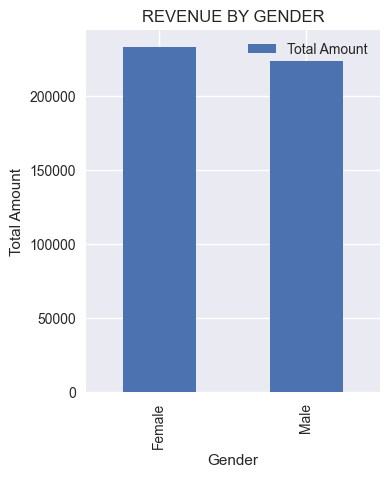

In [296]:
gender_df.plot(kind = 'bar', title = 'REVENUE BY GENDER', xlabel = 'Gender', ylabel = 'Total Amount', figsize = (3,3.7))

<Axes: ylabel='Total Amount'>

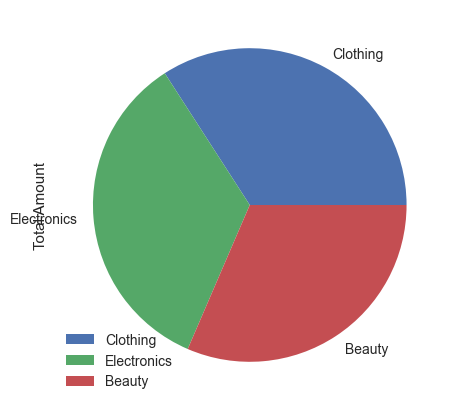

In [294]:
prod_df.plot.pie(y = 'Total Amount', figsize = (4,4))

<Axes: title={'center': 'MONTHLY REVENUE TREND'}, xlabel='Month', ylabel='No. of Transactions'>

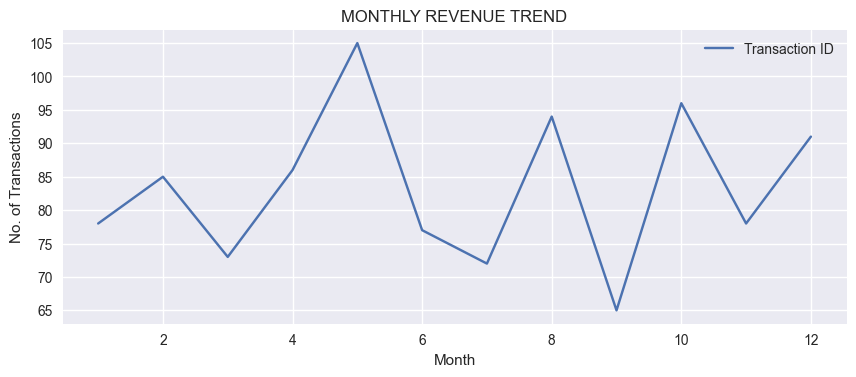

In [290]:
monthly_df.plot(kind = 'line', title = 'MONTHLY REVENUE TREND', xlabel = 'Month', ylabel = 'No. of Transactions', figsize = (8,3))